In [3]:
# import libraries
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# load directories
from hbn.constants import Defaults
from hbn.visualization import visualize as vis
from hbn.features.build_features import _index_dataframe_by_columns_values

import plotly.io as pio
pio.renderers.default = 'notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')



In [4]:
### DEFINE VARIABLES ###

model_parent = 'gender_mid_may'

models = glob.glob(os.path.join(Defaults.MODEL_DIR, model_parent, '*'))


### Load Results

In [5]:

# load model results
data = pd.DataFrame()
for model in models:
    # read model summary into pd dataframe
    df = pd.read_csv(os.path.join(model, 'model-summary.csv'), engine='python')

    df['features'] = df['feat_spec_name'].str.replace('features-', '')
    df['features'] = df['features'].str.replace('-remove-total-scores', '')
    df['demos'] = df['spec_name'].str.replace('participants-Reading-', '').str.replace('-spec', '')
    df['model_dir'] = model
    df['readers'] = df['Age_round'].map({'6_7_8': 'early', '9_10': 'emerging', '11_12_13_14_15_16_17_18': 'fluent'})

    # append dataframe
    data = pd.concat([data, df])


In [6]:
data['features'].unique()

array(['Child-language', 'all-internalizing-externalizing',
       'Parent-Stress', 'Child-intelligence', 'Child-emotional-status',
       'Child-reading', 'Child-production', 'Parent-CBCL', 'Parent-SES',
       'Child-reading-all-CORRECT', 'all-internalizing',
       'Child-internalizing', 'Child-externalizing',
       'Parent-internalizing', 'Parent-externalizing',
       'Teacher-internalizing', 'all-externalizing',
       'Teacher-externalizing'], dtype=object)

## Child Models

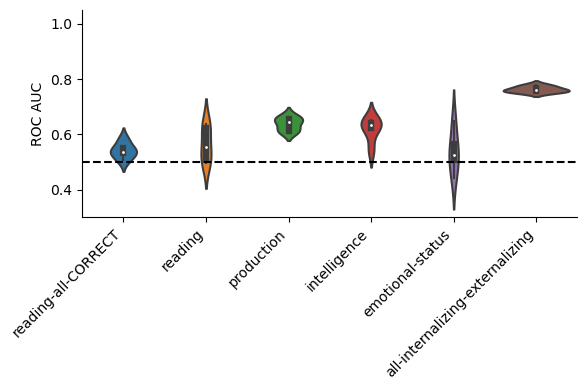

In [17]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child-language', 'all-internalizing-externalizing',
       'Child-reading-all-CORRECT', 'Child-intelligence', 'Child-emotional-status',
       'Child-reading', 'Child-production']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

fig = vis.violinplot(
            data=df_filter.sort_values(by=['features'], ascending=False), 
            y='roc_auc_score', 
            x='features', 
            # hue='Sex', 
            fig_title='',
            # legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            ylim=[.3, 1.05],
            # join_lines=False,
            # markers="D",
            # scale=0.6,
            figsize=(6,4)
            )


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-gender-child-measures.png'), bbox_inches='tight')

## Parent measures

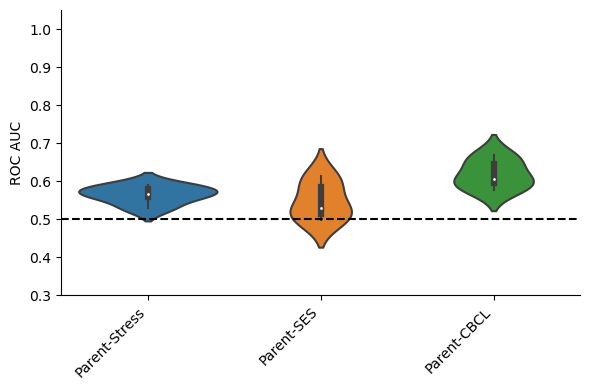

In [105]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Parent-Stress', 'Parent-CBCL', 'Parent-SES']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

fig = vis.violinplot(
            data=df_filter.sort_values(by=['features'], ascending=False), 
            y='roc_auc_score', 
            x='features', 
            # hue='Sex', 
            fig_title='',
            # legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            ylim=[.3, 1.05],
            # join_lines=False,
            # markers="D",
            # scale=0.6,
            figsize=(6,4)
            )


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-gender-parent-measures.png'), bbox_inches='tight')

## Child measuers: Early - Emerging - Fluent Readers

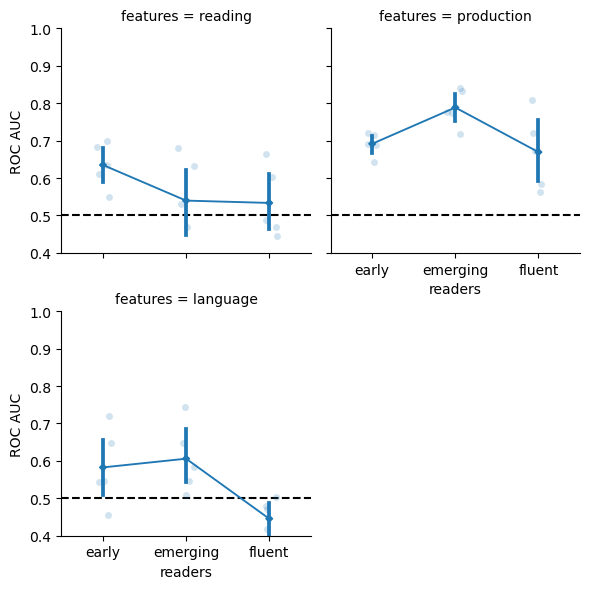

In [44]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-production', 'Child-language', 'Child-reading']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.refline(y=0.5, color='black', linestyle='--')
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score",  dodge=True, alpha=.2)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", markers="D", scale=0.5, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
plt.ylim([0.4, 1.0])
g.despine()
g.tight_layout()


g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-gender-development-production-language-reading.png'), bbox_inches='tight')

    

## Parent measuers: Early - Emerging - Fluent Readers

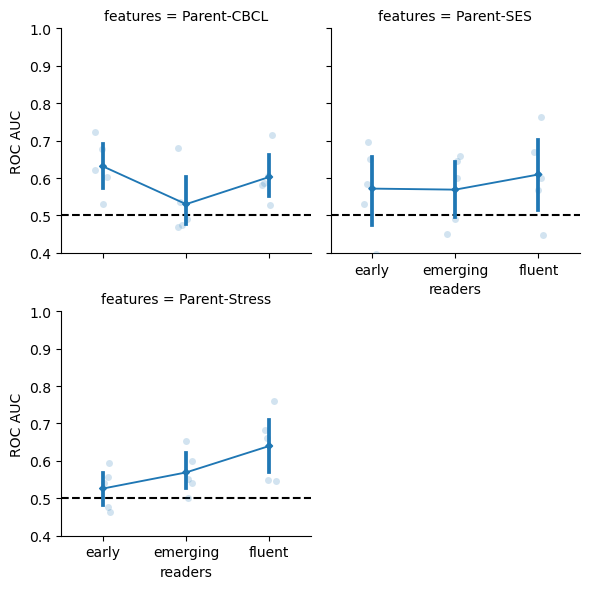

In [45]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Parent-Stress', 'Parent-CBCL', 'Parent-SES']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.refline(y=0.5, color='black', linestyle='--')
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score",  dodge=True, alpha=.2)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", markers="D", scale=0.5, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
plt.ylim([0.4, 1.0])
g.despine()
g.tight_layout()


g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-gender-development-parent.png'), bbox_inches='tight')

    

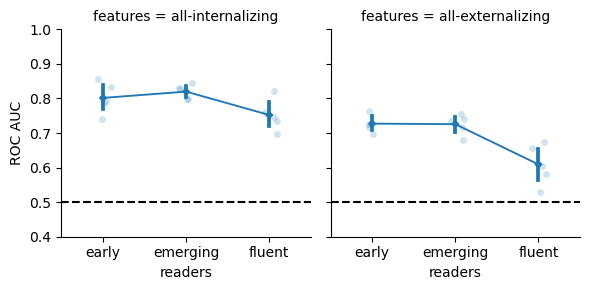

In [5]:

columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['all-internalizing',  'all-externalizing'] # all-externalizing (fluent)
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.refline(y=0.5, color='black', linestyle='--')
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score",  dodge=True, alpha=.2)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", markers="D", scale=0.5, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
plt.ylim([0.4, 1.0])
g.despine()
g.tight_layout()


g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-gender-development-internalizing-externalizing.png'), bbox_inches='tight')

    

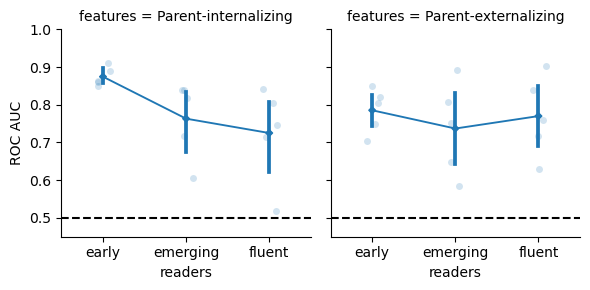

In [44]:

columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Parent-externalizing', 'Parent-internalizing']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

g = sns.FacetGrid(df_filter[df_filter['data']=='model-data'].sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.refline(y=0.5, color='black', linestyle='--')
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score",  dodge=True, alpha=.2)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", markers="D", scale=0.5, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
plt.ylim([0.45, 1.0])
g.despine()
g.tight_layout()


g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'models-gender-development-assessment-int-ext.png'), bbox_inches='tight')

    

In [48]:
df_groups = df_filter[df_filter['data']=='model-data'].groupby(['readers', 'features', 'splits'])['roc_auc_score'].mean().reset_index()


def two_way_anova(data, dependent_var, factor1, factor2):
    """
    Performs a two-way ANOVA test.

    Args:
        data: A pandas DataFrame containing the data.
        dependent_var: The name of the column containing the dependent variable.
        factor1: The name of the first factor column.
        factor2: The name of the second factor column.

    Returns:
        A pandas DataFrame containing the ANOVA table.
    """
    import pandas as pd
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    # Define the formula for the linear model
    formula = f"{dependent_var} ~ {factor1} + {factor2} + {factor1}:{factor2}"

    # Create the linear model
    model = ols(formula, data=data).fit()

    # Perform the ANOVA test
    anova_table = anova_lm(model)

    return anova_table

anova_results = two_way_anova(df_groups, "roc_auc_score", "readers", "features")
print(anova_results)

early_int = df_groups[(df_groups['features']=='Parent-internalizing') & (df_groups['readers']=='early')]['roc_auc_score']
emerging_int = df_groups[(df_groups['features']=='Parent-internalizing') & (df_groups['readers']=='emerging')]['roc_auc_score']
fluent_int = df_groups[(df_groups['features']=='Parent-internalizing') & (df_groups['readers']=='fluent')]['roc_auc_score']

# Bonferroni correction
def t_test_bonferroni(group1, group2, num_comparisons, alpha):
  statistic, p_value = ttest_ind(group1, group2, nan_policy='omit')
  corrected_p_val = p_value * num_comparisons
  significance = 'significant' if corrected_p_val < alpha else 'not significant'
  print(f'T-statistic: {statistic:.4f}, p-value: {p_value:.4f}, corrected p-value: {corrected_p_val:.4f}, significance: {significance}')

  return statistic, p_value, corrected_p_val, significance

# Correct for multiple comparisons
stat, p_val, corrected_p_val, significance = t_test_bonferroni(early_int, emerging_int, num_comparisons=15, alpha=0.05)



                    df    sum_sq   mean_sq         F    PR(>F)
readers            2.0  0.043925  0.021963  2.333896  0.118523
features           1.0  0.004123  0.004123  0.438129  0.514333
readers:features   2.0  0.022451  0.011226  1.192909  0.320692
Residual          24.0  0.225846  0.009410       NaN       NaN
T-statistic: 2.3762, p-value: 0.0448, corrected p-value: 0.6721, significance: not significant


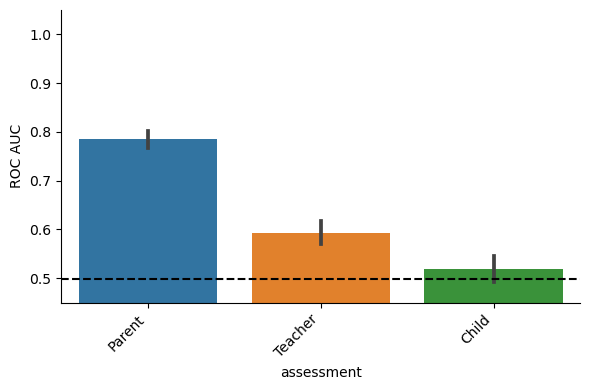

In [10]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child-internalizing', 'Child-externalizing',
       'Parent-internalizing', 'Parent-externalizing',
       'Teacher-internalizing', 
       'Teacher-externalizing']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()

df_filter['int_ext'] = df_filter['features'].str.extract('(externalizing|internalizing)')
df_filter['assessment'] = df_filter['features'].str.extract('(Teacher|Child|Parent)')

fig = vis.barplot(
            data=df_filter[df_filter['data']=='model-data'].sort_values(by='int_ext', ascending=False), 
            y='roc_auc_score', 
            x='assessment', 
            # hue='int_ext', 
            # fig_title='',
            # legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            ylim=[.45, 1.05],
            # join_lines=False,
            # markers="D",
            # scale=0.6,
            figsize=(6,4)
            )

# plot null model
null = df_filter[(df_filter['data']=='model-null')].groupby('assessment')['roc_auc_score'].mean().values
plt.axhline(y=null.mean(), color='k', linestyle='--')


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-int-ext-measures-assessments.png'), bbox_inches='tight')

In [30]:
from scipy.stats import f_oneway, ttest_ind

df_groups = df_filter[df_filter['data']=='model-data'].groupby(['assessment', 'splits'])['roc_auc_score'].mean().reset_index()

child = df_groups[df_groups['assessment']=='Child']['roc_auc_score']
parent = df_groups[df_groups['assessment']=='Parent']['roc_auc_score']
teacher = df_groups[df_groups['assessment']=='Teacher']['roc_auc_score']

assessments = [child, parent, teacher]

# Perform one-way ANOVA
F_statistic, p_value = f_oneway(*assessments)

# Print the results
print(f"F-statistic: {F_statistic:.4f}, p-value: {p_value:.4f}")

def t_test_bonferroni(group1, group2, num_comparisons, alpha):
  statistic, p_value = ttest_ind(group1, group2, nan_policy='omit')
  corrected_p_val = p_value * num_comparisons
  significance = 'significant' if corrected_p_val < alpha else 'not significant'
  print(f'T-statistic: {statistic:.4f}, p-value: {p_value:.4f}, corrected p-value: {corrected_p_val:.4f}, significance: {significance}')

  return statistic, p_value, corrected_p_val, significance

# Correct for multiple comparisons
stat, p_val, corrected_p_val, significance = t_test_bonferroni(parent, teacher, num_comparisons=3, alpha=0.05)




F-statistic: 145.1891, p-value: 0.0000
T-statistic: 15.0101, p-value: 0.0000, corrected p-value: 0.0000, significance: significant
